In [1]:
import pandas as pd
df = pd.read_csv('data/Courses.csv', encoding = 'utf-8', index_col = 0)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   course_id          641138 non-null  str    
 1   userid_DI          641138 non-null  str    
 2   registered         641138 non-null  int64  
 3   viewed             641138 non-null  int64  
 4   explored           641138 non-null  int64  
 5   certified          641138 non-null  int64  
 6   final_cc_cname_DI  641138 non-null  str    
 7   LoE_DI             535130 non-null  str    
 8   YoB                544533 non-null  float64
 9   gender             554332 non-null  str    
 10  grade              592766 non-null  str    
 11  start_time_DI      641138 non-null  str    
 12  last_event_DI      462184 non-null  str    
 13  nevents            441987 non-null  float64
 14  ndays_act          478395 non-null  float64
 15  nplay_video        183608 non-null  float64
 16  nchapters    

In [3]:
df.shape

(641138, 20)

In [4]:
print(df.duplicated().sum())

0


In [5]:
missing_summary = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_ratio(%)' : (df.isnull().mean()*100).round(2)
}).sort_values(by='missing_ratio(%)', ascending=False)
missing_summary

,missing_count,missing_ratio(%)
roles,641138,100.00
incomplete_flag,540977,84.38
nplay_video,457530,71.36
nchapters,258753,40.36
nevents,199151,31.06
last_event_DI,178954,27.91
ndays_act,162743,25.38
LoE_DI,106008,16.53
YoB,96605,15.07
gender,86806,13.54


In [6]:
df.head()

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
index,,,,,,,,,,,,,,,,,,,,
0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,NaN,1.0
1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaN,NaN,9.0,NaN,1.0,0,NaN,1.0
2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,NaN,1.0
3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0
4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0


In [7]:
df.describe()

,registered,viewed,explored,certified,YoB,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
count,641138.0,641138.000000,641138.000000,641138.000000,544533.000000,441987.000000,478395.000000,183608.000000,382385.000000,641138.000000,0.0,100161.0
mean,1.0,0.624299,0.061899,0.027587,1985.253279,431.008018,5.710254,114.844173,3.634423,0.018968,NaN,1.0
std,0.0,0.484304,0.240973,0.163786,8.891814,1516.116057,11.866471,426.996844,4.490987,0.229539,NaN,0.0
min,1.0,0.000000,0.000000,0.000000,1931.000000,1.000000,1.000000,1.000000,1.000000,0.000000,NaN,1.0
25%,1.0,0.000000,0.000000,0.000000,1982.000000,3.000000,1.000000,5.000000,1.000000,0.000000,NaN,1.0
50%,1.0,1.000000,0.000000,0.000000,1988.000000,24.000000,2.000000,18.000000,2.000000,0.000000,NaN,1.0
75%,1.0,1.000000,0.000000,0.000000,1991.000000,158.000000,4.000000,73.000000,4.000000,0.000000,NaN,1.0
max,1.0,1.000000,1.000000,1.000000,2013.000000,197757.000000,205.000000,98517.000000,48.000000,20.000000,NaN,1.0


In [8]:
df['YoB'].value_counts()

YoB
1990.0    38524
1992.0    37846
1991.0    37544
1989.0    36831
1988.0    34436
          ...  
2003.0       10
2009.0        8
1931.0        7
2007.0        6
1934.0        5
Name: count, Length: 78, dtype: int64

- 나이 정제

<Axes: >

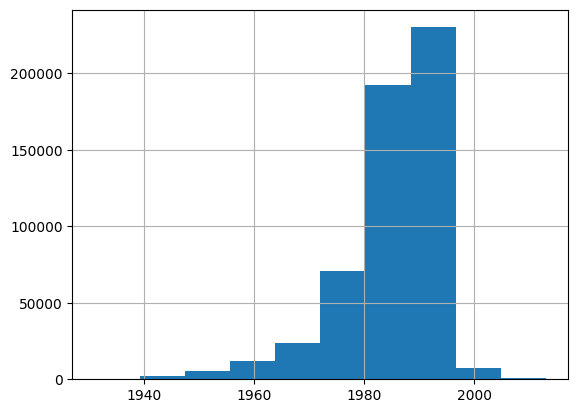

In [9]:
df['YoB'].hist()

In [10]:
df['registered'].value_counts(normalize=True)*100

registered
1    100.0
Name: proportion, dtype: float64

In [11]:
df['viewed'].value_counts(normalize=True)*100

viewed
1    62.429929
0    37.570071
Name: proportion, dtype: float64

In [12]:
df['explored'].value_counts(normalize=True)*100

explored
0    93.810069
1     6.189931
Name: proportion, dtype: float64

In [13]:
df['certified'].value_counts(normalize=True)*100

certified
0    97.241312
1     2.758688
Name: proportion, dtype: float64

In [14]:
# 이벤트가 있는데 활동일수가 없는 경우 
events_act = df.loc[(df['nevents'].notna()) & ((df['ndays_act'].isna()))]
print(len(events_act))

0


In [15]:
# 강의를 열람하지 않았는데 인증서를 획득한 경우
viewed_certified = df.loc[(df['viewed'] == 0) & (df['certified'] == 1)]
print(len(viewed_certified))

0


In [48]:
# 강의를 열람하지 않았는데 적극 탐색한 경우 **
viewed_explored = df.loc[((df['viewed'] == 0) | df['viewed'].isna()) & (df['explored'] == 1)]
print(f"강의를 열람하지 않았는데 적극 탐색한 경우 : {len(viewed_explored)}")
display(viewed_explored)

강의를 열람하지 않았는데 적극 탐색한 경우 : 8


,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
index,,,,,,,,,,,,,,,,,,,,
365180,MITx/6.002x/2012_Fall,MHxPC130007852,1,0,1,0,Other Middle East/Central Asia,NaN,NaN,NaN,0,2012-09-30,2013-01-07,10.0,2.0,NaN,17.0,0,NaN,NaN
370050,MITx/6.002x/2012_Fall,MHxPC130167688,1,0,1,0,United States,NaN,NaN,NaN,0,2012-11-03,2012-11-04,2.0,1.0,NaN,17.0,0,NaN,NaN
571332,MITx/8.02x/2013_Spring,MHxPC130562889,1,0,1,0,China,NaN,NaN,NaN,0,2013-02-21,2013-02-21,1.0,1.0,NaN,10.0,0,NaN,NaN
626905,MITx/8.02x/2013_Spring,MHxPC130501631,1,0,1,0,Canada,Secondary,1993.0,m,0,2013-06-12,NaN,NaN,1.0,NaN,16.0,0,NaN,1.0
630822,MITx/8.02x/2013_Spring,MHxPC130414770,1,0,1,0,United States,Secondary,1996.0,m,NaN,2013-08-26,2013-08-26,1.0,1.0,NaN,11.0,0,NaN,NaN
631023,MITx/6.002x/2013_Spring,MHxPC130426148,1,0,1,0,Other South Asia,Secondary,1995.0,m,NaN,2013-07-23,2013-07-27,30.0,2.0,NaN,16.0,0,NaN,NaN
635912,MITx/6.00x/2013_Spring,MHxPC130585243,1,0,1,0,United States,Bachelor's,1989.0,f,NaN,2013-08-15,2013-08-15,2.0,1.0,NaN,17.0,0,NaN,NaN
636492,MITx/6.00x/2013_Spring,MHxPC130541801,1,0,1,0,United States,Bachelor's,1980.0,m,NaN,2013-08-18,NaN,NaN,NaN,NaN,17.0,0,NaN,1.0


In [81]:
# 강의를 열람했는데 이벤트가 발생하지 않은 경우 ** 
viewed_nevents = df.loc[(df['viewed'] == 1) & ((df['nevents'].isna()))]
print(f"강의를 열람했는데 이벤트가 발생하지 않은 경우 : {len(viewed_nevents)}")
display(viewed_nevents)

강의를 열람했는데 이벤트가 발생하지 않은 경우 : 76055


,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
index,,,,,,,,,,,,,,,,,,,,
1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaT,NaN,9.0,NaN,1.0,0,NaN,1.0
9,HarvardX/CS50x/2012,MHxPC130088379,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-20,NaT,NaN,12.0,NaN,3.0,0,NaN,1.0
13,HarvardX/CS50x/2012,MHxPC130024894,1,1,0,0,United States,NaN,NaN,NaN,0,2013-06-27,NaT,NaN,2.0,NaN,2.0,0,NaN,1.0
17,HarvardX/CS50x/2012,MHxPC130080986,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaT,NaN,11.0,NaN,1.0,0,NaN,1.0
19,HarvardX/CS50x/2012,MHxPC130063375,1,1,0,0,Unknown/Other,NaN,NaN,NaN,0,2012-10-19,NaT,NaN,NaN,NaN,1.0,0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627946,MITx/3.091x/2013_Spring,MHxPC130085848,1,1,0,0,United Kingdom,Secondary,1993.0,m,0,2013-06-20,NaT,NaN,1.0,NaN,2.0,0,NaN,1.0
628463,MITx/6.00x/2013_Spring,MHxPC130425760,1,1,0,0,Unknown/Other,NaN,NaN,NaN,0,2013-06-24,NaT,NaN,NaN,NaN,NaN,0,NaN,NaN
631112,MITx/6.002x/2013_Spring,MHxPC130517703,1,1,0,0,Unknown/Other,Bachelor's,1991.0,m,NaN,2013-07-23,NaT,NaN,NaN,NaN,4.0,0,NaN,1.0


In [44]:
certified_count = viewed_nevents['certified'].sum()
certified_rate = (certified_count / 76055)*100
ndays_act = viewed_nevents['ndays_act'].mean()

print(f"이 그룹의 수료자 수 : {certified_count}")
print(f"이 그룹의 수료율 : {certified_rate}")
print(f"이 그룹의 평균 활동일 : {ndays_act}")

이 그룹의 수료자 수 : 12
이 그룹의 수료율 : 0.015778055354677537
이 그룹의 평균 활동일 : 4.19115711904553


In [ ]:
certified_12_users = viewed_nevents.loc[viewed_nevents['certified'] == 1, 'userid_DI']
print(f"이 그룹의 유저아이디 : {certified_12_users}")
display(viewed_nevents[viewed_nevents['certified'] == 1])

이 그룹의 유저아이디 : index
106843    MHxPC130306856
144691    MHxPC130033009
213275    MHxPC130522075
252887    MHxPC130410256
319145    MHxPC130328116
325969    MHxPC130095114
396575    MHxPC130292274
462248    MHxPC130383454
514799    MHxPC130276145
547604    MHxPC130043740
555757    MHxPC130074389
586586    MHxPC130333390
Name: userid_DI, dtype: str


,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
index,,,,,,,,,,,,,,,,,,,,
106843,HarvardX/CS50x/2012,MHxPC130306856,1,1,1,1,Unknown/Other,Doctorate,1968.0,m,1,2012-11-30,NaT,NaN,NaN,NaN,12.0,0,NaN,1.0
144691,HarvardX/PH207x/2012_Fall,MHxPC130033009,1,1,1,1,Other South Asia,Master's,1975.0,m,0.96,2012-10-17,NaT,NaN,NaN,NaN,15.0,0,NaN,1.0
213275,HarvardX/PH278x/2013_Spring,MHxPC130522075,1,1,1,1,Unknown/Other,Secondary,1993.0,m,0.81,2013-03-17,NaT,NaN,NaN,NaN,10.0,0,NaN,1.0
252887,HarvardX/PH278x/2013_Spring,MHxPC130410256,1,1,1,1,Other South Asia,Secondary,1992.0,m,0.81,2013-03-01,NaT,NaN,NaN,NaN,9.0,0,NaN,1.0
319145,HarvardX/ER22x/2013_Spring,MHxPC130328116,1,1,1,1,Unknown/Other,Secondary,1994.0,m,0.69,2013-06-23,NaT,NaN,NaN,NaN,31.0,0,NaN,1.0
325969,HarvardX/ER22x/2013_Spring,MHxPC130095114,1,1,0,1,Unknown/Other,Secondary,1993.0,m,1,2013-07-22,NaT,NaN,NaN,NaN,8.0,0,NaN,1.0
396575,MITx/6.00x/2012_Fall,MHxPC130292274,1,1,1,1,Unknown/Other,NaN,NaN,m,0.6,2012-08-13,NaT,NaN,NaN,NaN,17.0,0,NaN,1.0
462248,MITx/6.00x/2012_Fall,MHxPC130383454,1,1,1,1,Unknown/Other,Secondary,1993.0,m,0.63,2012-10-01,NaT,NaN,NaN,NaN,9.0,0,NaN,1.0
514799,MITx/6.002x/2013_Spring,MHxPC130276145,1,1,1,1,India,Secondary,1992.0,m,0.77,2012-12-27,NaT,NaN,NaN,NaN,17.0,1,NaN,1.0


- 강의 열람은 했지만 이벤트가 발생하지 않은 그룹(76055명) 중 12명만 수료 : 이 데이터의 경우 실제 학습 행동을 대변하지 못하는 것으로 보임
- 이벤트가 발생하지 않았는데 평균 활동일 4일 : 로그인 후 자동 출석?

In [61]:
# 강의를 열람했으나 영상 재생 수가 존재하지 않는 경우
viewed_video = df.loc[df['viewed'] == 1 & df['nplay_video'].isna()]
print(f"강의를 열람했으나 영상 재생 수가 존재하지 않은 경우 : {len(viewed_video)}")
display(viewed_video)

강의를 열람했으나 영상 재생 수가 존재하지 않은 경우 : 216906


,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
index,,,,,,,,,,,,,,,,,,,,
1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaN,NaN,9.0,NaN,1.0,0,NaN,1.0
7,HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,NaN,NaN,NaN,0,2013-01-01,2013-05-14,42.0,6.0,NaN,3.0,0,NaN,NaN
8,HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,NaN,NaN,NaN,0,2013-02-18,2013-03-17,70.0,3.0,NaN,3.0,0,NaN,NaN
9,HarvardX/CS50x/2012,MHxPC130088379,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-20,NaN,NaN,12.0,NaN,3.0,0,NaN,1.0
10,HarvardX/ER22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,NaN,NaN,NaN,0,2013-02-23,2013-06-14,17.0,2.0,NaN,2.0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641102,MITx/6.00x/2013_Spring,MHxPC130024301,1,1,0,0,Morocco,Secondary,1994.0,m,NaN,2013-09-07,2013-09-07,25.0,1.0,NaN,2.0,0,NaN,NaN
641113,MITx/8.MReV/2013_Summer,MHxPC130261281,1,1,0,0,India,Secondary,1994.0,m,0,2013-09-07,2013-09-07,8.0,1.0,NaN,1.0,0,NaN,NaN
641120,MITx/8.MReV/2013_Summer,MHxPC130374105,1,1,0,0,India,Bachelor's,1992.0,m,0,2013-09-07,2013-09-07,49.0,1.0,NaN,1.0,0,NaN,NaN


- 강의를 열람했는데 이벤트가 발생하지 않음
- 영상 재생을 하지 않았는데 탐색한 챕터는 존재함

In [46]:
# 인증서를 획득했으나 적극 탐색을 하지 않은 경우 **
# 수료 기준이 매우 낮을 가능성
certified_explored = df.loc[(df['certified'] == 1) & ((df['explored'] == 0) | df['explored'].isna())]
print(f"인증서를 획득했으나 적극 탐색하지 않은 경우 : {len(certified_explored)}")
display(certified_explored)

인증서를 획득했으나 적극 탐색하지 않은 경우 : 690


,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
index,,,,,,,,,,,,,,,,,,,,
361,HarvardX/ER22x/2013_Spring,MHxPC130306723,1,1,0,1,United Kingdom,NaN,NaN,NaN,0.62,2012-12-19,2013-08-15,494.0,24.0,NaN,10.0,0,NaN,NaN
1416,HarvardX/PH278x/2013_Spring,MHxPC130550925,1,1,0,1,United States,NaN,NaN,NaN,0.53,2013-01-20,2013-06-24,906.0,13.0,69.0,4.0,0,NaN,NaN
2378,HarvardX/ER22x/2013_Spring,MHxPC130511497,1,1,0,1,Other Middle East/Central Asia,NaN,NaN,NaN,0.92,2013-06-07,2013-06-29,290.0,3.0,NaN,9.0,0,NaN,NaN
5588,HarvardX/ER22x/2013_Spring,MHxPC130083734,1,1,0,1,Brazil,NaN,NaN,NaN,0.63,2013-01-23,2013-08-16,663.0,14.0,NaN,9.0,0,NaN,NaN
6643,HarvardX/ER22x/2013_Spring,MHxPC130536126,1,1,0,1,Colombia,NaN,NaN,NaN,1,2013-01-31,2013-09-02,680.0,27.0,NaN,12.0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
622287,MITx/8.MReV/2013_Summer,MHxPC130394638,1,1,0,1,India,Secondary,1995.0,m,0.6,2013-05-27,2013-08-20,4964.0,28.0,1.0,22.0,0,NaN,NaN
622426,MITx/8.MReV/2013_Summer,MHxPC130059185,1,1,0,1,United States,Secondary,1996.0,m,0.62,2013-05-27,2013-07-23,3439.0,17.0,4.0,23.0,0,NaN,NaN
622752,MITx/8.MReV/2013_Summer,MHxPC130285078,1,1,0,1,United States,Less than Secondary,1997.0,m,0.61,2013-05-28,2013-08-22,3049.0,25.0,NaN,22.0,0,NaN,NaN


In [19]:
# 활동일이 없으나 이벤트가 발생한 경우
ghost_activity = df[(df['start_time_DI'].isna() | df['last_event_DI'].isna()) & (df['nevents']) > 0.0]
print(len(ghost_activity))

0


In [78]:
# 활동일 순서 확인 **
time = df.loc[df['last_event_DI'] < df['start_time_DI']]
print(f"마지막 활동일이 강의 시작일 보다 빠른 경우 : {len(time)}")
display(time)

마지막 활동일이 강의 시작일 보다 빠른 경우 : 1443


,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
index,,,,,,,,,,,,,,,,,,,,
244,HarvardX/CS50x/2012,MHxPC130464231,1,1,0,0,India,NaN,NaN,NaN,0,2013-08-18,2013-03-16,1.0,1.0,NaN,1.0,0,NaN,NaN
261,HarvardX/CS50x/2012,MHxPC130216109,1,1,0,0,Canada,NaN,NaN,NaN,0.0,2013-08-17,2013-03-15,1.0,1.0,NaN,1.0,0,NaN,NaN
775,HarvardX/CS50x/2012,MHxPC130591769,1,1,1,0,Ukraine,NaN,NaN,NaN,0,2013-08-27,2013-05-24,51.0,3.0,NaN,8.0,0,NaN,NaN
930,HarvardX/ER22x/2013_Spring,MHxPC130019081,1,1,0,0,United Kingdom,NaN,NaN,NaN,NaN,2013-07-30,2013-04-27,862.0,16.0,NaN,14.0,2,NaN,NaN
1091,HarvardX/CS50x/2012,MHxPC130295771,1,1,0,0,Other Europe,NaN,NaN,NaN,0,2013-07-19,2013-04-07,1.0,1.0,NaN,2.0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631895,MITx/6.002x/2013_Spring,MHxPC130305552,1,0,0,0,India,Secondary,1994.0,m,NaN,2013-07-31,2013-07-26,3.0,1.0,NaN,NaN,0,NaN,NaN
631907,MITx/6.002x/2013_Spring,MHxPC130502670,1,1,0,0,United States,Master's,1982.0,m,NaN,2013-07-29,2013-07-26,10.0,1.0,2.0,1.0,0,NaN,NaN
632350,MITx/6.002x/2013_Spring,MHxPC130399133,1,0,0,0,India,Secondary,1995.0,m,NaN,2013-08-27,2013-08-15,2.0,2.0,NaN,NaN,0,NaN,NaN


In [79]:
time_mask = df['last_event_DI'] < df['start_time_DI']
df.loc[time_mask, ['start_time_DI', 'last_event_DI', 'ndays_act']].sort_values(by='ndays_act', ascending=False)

,start_time_DI,last_event_DI,ndays_act
index,,,
374635,2013-02-14,2013-02-01,84.0
46151,2013-05-21,2013-05-10,54.0
440363,2013-08-25,2013-06-08,50.0
347991,2013-06-04,2013-01-19,48.0
145542,2013-01-23,2013-01-20,47.0
...,...,...,...
619372,2013-06-16,2013-05-19,1.0
619584,2013-05-24,2013-05-23,1.0
619682,2013-08-17,2013-05-20,1.0


- 마지막 활동일 - 강의 시작일이 음수인데 활동일이 84일 되는 말이 안되는 경우

----------

In [94]:
import pandas as pd
df = pd.read_csv('data/course_fixed.csv', encoding = 'utf-8', index_col = 0) 

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8044\1712771008.py:2: DtypeWarning: Columns (0: YoB, 1: grade) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/course_fixed.csv', encoding = 'utf-8', index_col = 0)


In [99]:
df.loc[df['course_id'] == 'HarvardX/ER22x/2013_Spring', 'nplay_video'].value_counts()

nplay_video
0.0    12389
Name: count, dtype: int64